# Audio

In [1]:
# autotime prints how long every cell took -- useful when you start timing
# model calls against API calls.
%load_ext autotime

time: 167 µs (started: 2026-08-25 21:09:28 +05:30)


In [2]:
import os, json, base64, subprocess, warnings
from pathlib import Path

import numpy as np
import librosa
import soundfile as sf
import torch
import cv2
import matplotlib.pyplot as plt
from IPython.display import Audio, display

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white",
    "axes.facecolor": "#FCFAF4", "axes.grid": True,
    "grid.color": "#E6E0D4", "axes.titleweight": "bold", "font.size": 10,
})

device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")

print("numpy", np.__version__, "| librosa", librosa.__version__,
      "| torch", torch.__version__, "| cv2", cv2.__version__)
print("device:", device)

numpy 2.3.3 | librosa 0.11.0 | torch 2.10.0 | cv2 4.13.0
device: mps
time: 1.89 s (started: 2026-08-25 21:09:32 +05:30)


In [3]:
import textwrap
from dotenv import load_dotenv
from openai import OpenAI

# Optional -- only needed if you are behind a VPN, as I am.
import truststore
truststore.inject_into_ssl()


def pretty_print(*args):
    text = " ".join(str(arg) for arg in args)
    try:
        print(textwrap.fill(text, width=80))
    except Exception:
        print(text)


load_dotenv('/Users/shivam13juna/Documents/scaler/GEN_AI_REF/openai_key.env')

if not os.getenv("OPENAI_API_KEY"):
    raise ValueError("OPENAI_API_KEY not found! Check the path in load_dotenv above.")

client = OpenAI()
pretty_print("API key loaded, client ready.")

API key loaded, client ready.
time: 479 ms (started: 2026-08-25 21:09:42 +05:30)


In [4]:
# ---- everything the notebook is configured by, in one place ---------------

SR = 16_000                              # THE speech sample rate. Everything is 16k.

ASR_MODEL_ID = "openai/whisper-base.en"  # fast classroom default (73M params)
# ASR_MODEL_ID = "openai/whisper-large-v3-turbo"   # what you'd actually ship

VISION_MODEL = "gpt-5-nano"              # any vision model: gpt-4o, gpt-4.1, gpt-5-*
OPENAI_ASR   = "gpt-4o-transcribe"       # managed speech-to-text
OPENAI_TTS   = "gpt-4o-mini-tts"         # managed text-to-speech
SEGMENT_ASR  = "whisper-1"               # the only one that returns SEGMENT timestamps

VIDEO_PATH = "/Users/shivam13juna/Documents/scaler/GEN_AI_REF/AI Modalities: Video/videos/what_is_your_name.mp4"

CACHE = Path("audio_cache")              # pre-fetched clips live here

print("ASR (local) :", ASR_MODEL_ID)
print("vision      :", VISION_MODEL)
print("video       :", Path(VIDEO_PATH).name, "|  exists:", os.path.exists(VIDEO_PATH))

ASR (local) : openai/whisper-base.en
vision      : gpt-5-nano
video       : what_is_your_name.mp4 |  exists: True
time: 1.55 ms (started: 2026-08-25 21:10:56 +05:30)


In [6]:
#20Hz to 20kHz is the human hearing range. 16kHz is a good compromise for speech, and is what Whisper uses.

time: 118 µs (started: 2026-08-25 21:14:06 +05:30)


In [11]:
# Frequency = how fast the wave wobbles = what you hear as PITCH.
# Same amplitude (0.3) every time, so the ONLY thing changing is speed.
sr_demo, duration = 44_100, 2.0
t = np.linspace(0, duration, int(sr_demo * duration), endpoint=False)

for hz, label in [(100, "deep"), (1000, "sharp"), (10_000, "very sharp"),
                  (15_000, "near the top of adult hearing"), (18_000, "near the top of young adult hearing"), (20_000, "top of human hearing"), (25_000, "beyond human hearing")]:
    print(f"{hz:>6} Hz  ({label})")
    display(Audio(0.3 * np.sin(2 * np.pi * hz * t), rate=sr_demo))

   100 Hz  (deep)


  1000 Hz  (sharp)


 10000 Hz  (very sharp)


 15000 Hz  (near the top of adult hearing)


 18000 Hz  (near the top of young adult hearing)


 20000 Hz  (top of human hearing)


 25000 Hz  (beyond human hearing)


time: 10.4 ms (started: 2026-08-25 21:19:31 +05:30)


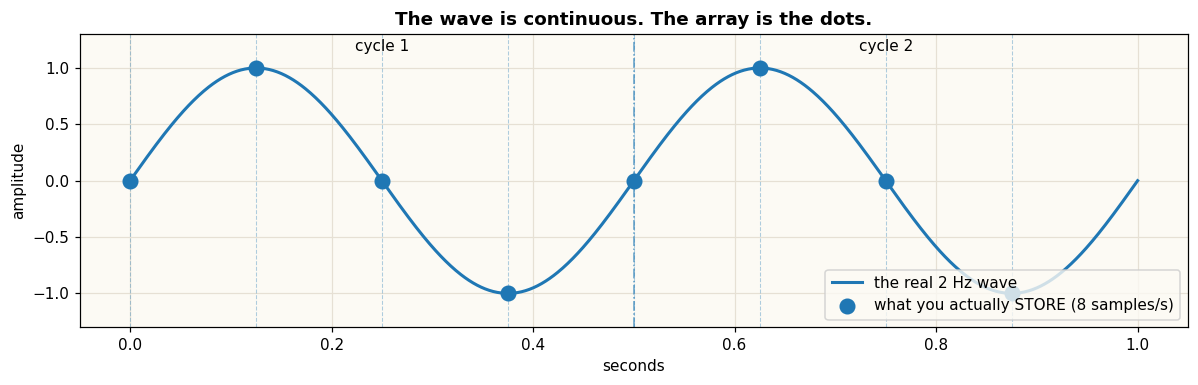

samples per cycle: 4.0
the array you'd store: [ 0.  1.  0. -1. -0.  1.  0. -1.]
time: 137 ms (started: 2026-08-25 21:21:43 +05:30)


In [12]:
sound_frequency = 2      # 2 cycles per second
sampling_rate   = 8      # 8 measurements per second

t_smooth  = np.linspace(0, 1.0, 1000)
y_smooth  = np.sin(2 * np.pi * sound_frequency * t_smooth)
t_samples = np.arange(0, 1.0, 1 / sampling_rate)
y_samples = np.sin(2 * np.pi * sound_frequency * t_samples)

plt.figure(figsize=(11, 3.6))
plt.plot(t_smooth, y_smooth, lw=2, label=f"the real {sound_frequency} Hz wave")
plt.scatter(t_samples, y_samples, s=90, zorder=3,
            label=f"what you actually STORE ({sampling_rate} samples/s)")
for tick in t_samples:
    plt.axvline(tick, ls="--", lw=0.7, alpha=0.35)
plt.axvline(0.5, ls="-.", lw=1, alpha=0.7)
plt.text(0.25, 1.15, "cycle 1", ha="center"); plt.text(0.75, 1.15, "cycle 2", ha="center")
plt.title("The wave is continuous. The array is the dots."); plt.xlabel("seconds")
plt.ylabel("amplitude"); plt.ylim(-1.3, 1.3); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

print("samples per cycle:", sampling_rate / sound_frequency)
print("the array you'd store:", np.round(y_samples, 2))

In [ ]:
# A cached LibriSpeech clip. Decoded with soundfile (never torchcodec).
y16, sr0 = sf.read(CACHE / "librispeech_dummy.wav", dtype="float32")
ref_text = json.load(open(CACHE / "librispeech_dummy_meta.json"))["ref_text"]

print(f"samples  : {len(y16):,}   sr: {sr0} Hz   duration: {len(y16)/sr0:.2f}s")
print(f"dtype    : {y16.dtype}   range: [{y16.min():+.3f}, {y16.max():+.3f}]"
      "   <- floats in [-1, 1], which is what models want")
print(f"reference: {ref_text!r}")
display(Audio(y16, rate=SR))

samples  : 93,680   sr: 16000 Hz   duration: 5.86s
dtype    : float32   range: [-0.339, +0.388]   <- floats in [-1, 1], which is what models want
reference: 'MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL'


time: 2.58 ms (started: 2026-08-25 21:29:54 +05:30)


16k times in a second. 

In [13]:
import transformers
from transformers import WhisperProcessor, WhisperForConditionalGeneration

warnings.filterwarnings("ignore")
transformers.logging.set_verbosity_error()   # HF's generation notices are noisy in class

processor = WhisperProcessor.from_pretrained(ASR_MODEL_ID)
model = WhisperForConditionalGeneration.from_pretrained(ASR_MODEL_ID).to(device).eval()

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"loaded {ASR_MODEL_ID}  (~{n_params:.0f}M params) on {device}")

objc[15114]: Class AVFFrameReceiver is implemented in both /Users/shivam13juna/Documents/virtual_envs/dev3.12/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1158f03a8) and /Users/shivam13juna/Documents/virtual_envs/dev3.12/lib/python3.12/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x11edac3a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[15114]: Class AVFAudioReceiver is implemented in both /Users/shivam13juna/Documents/virtual_envs/dev3.12/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x1158f03f8) and /Users/shivam13juna/Documents/virtual_envs/dev3.12/lib/python3.12/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x11edac3f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

loaded openai/whisper-base.en  (~73M params) on mps
time: 13.5 s (started: 2026-08-25 21:28:51 +05:30)


In [17]:
# NOTE sampling_rate=16_000. This MUST match the audio's true rate --
# it is the Part 3 footgun, made concrete right here.
feats = processor(y16, sampling_rate=SR, return_tensors="pt").input_features.to(device)
print("input_features:", tuple(feats.shape), "= (batch, 80 mel bands, frames)")

with torch.no_grad():
    ids = model.generate(feats, max_new_tokens=128)

hyp = processor.batch_decode(ids, skip_special_tokens=True)[0].strip()
print("\nhypothesis:", hyp)
print("reference :", ref_text)

input_features: (1, 80, 3000) = (batch, 80 mel bands, frames)

hypothesis: Mr. Quilter is the apostle of the middle classes, and we are glad to welcome his gospel.
reference : MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL
time: 918 ms (started: 2026-08-25 21:31:50 +05:30)


In [18]:
from jiwer import wer

_ref = "the quick brown fox jumps over the lazy dog"
_hyp = "the quick brown fox jump over lazy dog"       # 1 substitution + 1 deletion

print("reference :", _ref)
print("hypothesis:", _hyp)
print(f"WER       : {wer(_ref, _hyp):.3f}   (2 errors / 9 reference words)")

reference : the quick brown fox jumps over the lazy dog
hypothesis: the quick brown fox jump over lazy dog
WER       : 0.222   (2 errors / 9 reference words)
time: 64.1 ms (started: 2026-08-25 21:35:07 +05:30)


In [20]:
vad_model, vad_utils = torch.hub.load("snakers4/silero-vad", "silero_vad",
                                      trust_repo=True)
get_speech_timestamps = vad_utils[0]

# Silero wants 16 kHz mono float32 as a torch tensor.
speech = get_speech_timestamps(torch.from_numpy(np.ascontiguousarray(y16)),
                               vad_model, sampling_rate=SR, return_seconds=True)

print(f"clip is {len(y16)/SR:.2f}s long; VAD found {len(speech)} speech segment(s):")
for s in speech:
    print(f"  speech {s['start']:.2f}s -> {s['end']:.2f}s")

clip is 5.86s long; VAD found 1 speech segment(s):
  speech 0.50s -> 5.50s
time: 423 ms (started: 2026-08-25 21:38:54 +05:30)


Using cache found in /Users/shivam13juna/.cache/torch/hub/snakers4_silero-vad_master


In [19]:
# --- speech -> text --------------------------------------------------------
with open("test_audio.wav", "rb") as audio_file:
    transcription = client.audio.transcriptions.create(
        model=OPENAI_ASR,
        file=audio_file,
    )

print("transcribed:", transcription.text)

# Audio is billed as TOKENS too -- and they are input tokens, like any prompt.
u = transcription.usage
print("\ninput tokens :", u.input_tokens, " of which audio:",
      u.input_token_details.audio_tokens)
print("output tokens:", u.output_tokens, "| total:", u.total_tokens)

transcribed: Hello testing one two three.

input tokens : 34  of which audio: 34
output tokens: 8 | total: 42
time: 2.93 s (started: 2026-08-25 21:37:00 +05:30)


In [21]:
# --- text -> speech --------------------------------------------------------
speech_file_path = Path("tutor_voice.mp3")

with client.audio.speech.with_streaming_response.create(
    model=OPENAI_TTS,
    voice="nova",                      # alloy, echo, fable, onyx, nova, shimmer
    input="Hello students! Today we will explore AI that can see, listen, and speak. And also eat your wallet."
) as response:
    response.stream_to_file(speech_file_path)

print("saved:", speech_file_path, f"({speech_file_path.stat().st_size/1024:.0f} KB)")
display(Audio(str(speech_file_path)))

saved: tutor_voice.mp3 (125 KB)


time: 4.05 s (started: 2026-08-25 21:40:33 +05:30)
